### 1. LOAD DATA

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("raw_behavior_data.csv")

### 2. BASIC UNDERSTANDING

In [7]:
print(df.head())        # First 5 rows
print(df.tail())        # Last 5 rows
print(df.shape)         # Rows & Columns
print(df.columns)       # Column names

  User_ID  Age Gender  Screen_Time_Hours  Sleep_Hours      App_Usage    Steps  \
0    U001   56   Male              11.30          NaN           Work   4471.0   
1    U002   46   Male              10.31         4.41         Gaming  10028.0   
2    U003   32  Other              11.65         7.40   Social Media   6624.0   
3    U004   25   Male               3.24         7.27           Work   9691.0   
4    U005   38  Other               9.31         5.37  Entertainment  14884.0   

       Mood  Work_Hours  Social_Interactions  
0   Neutral        4.50                   17  
1   Neutral       11.07                   12  
2     Happy        7.59                   21  
3   Neutral        8.08                   11  
4  Stressed        9.01                    5  
    User_ID  Age  Gender  Screen_Time_Hours  Sleep_Hours      App_Usage  \
495    U496   56  Female               6.26         4.76  Entertainment   
496    U497   49   Other               6.51         4.31           Work   
497   

### 3. DATA INFO

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   User_ID              500 non-null    object 
 1   Age                  500 non-null    int64  
 2   Gender               500 non-null    object 
 3   Screen_Time_Hours    500 non-null    float64
 4   Sleep_Hours          475 non-null    float64
 5   App_Usage            500 non-null    object 
 6   Steps                475 non-null    float64
 7   Mood                 500 non-null    object 
 8   Work_Hours           500 non-null    float64
 9   Social_Interactions  500 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 39.2+ KB


### 4. STATISTICAL SUMMARY

In [13]:
df.describe()

,Age,Screen_Time_Hours,Sleep_Hours,Steps,Work_Hours,Social_Interactions
count,500.000000,500.000000,475.000000,475.000000,500.000000,500.000000
mean,39.326000,7.091260,6.490989,8106.164211,8.022200,15.468000
std,12.200386,2.943077,1.450377,4104.728354,2.363768,8.560581
min,18.000000,2.050000,4.020000,1007.000000,4.000000,1.000000
25%,29.000000,4.387500,5.170000,4659.000000,6.062500,8.000000
50%,41.000000,7.275000,6.510000,8156.000000,8.010000,16.000000
75%,50.000000,9.685000,7.675000,11551.500000,10.122500,23.000000
max,59.000000,11.980000,9.000000,14992.000000,11.980000,29.000000


### 5. CHECK MISSING VALUES

In [16]:
df.isnull().sum()

User_ID                 0
Age                     0
Gender                  0
Screen_Time_Hours       0
Sleep_Hours            25
App_Usage               0
Steps                  25
Mood                    0
Work_Hours              0
Social_Interactions     0
dtype: int64

### 6. HANDLE MISSING VALUES

In [19]:
# Fill numerical columns

df["Sleep_Hours"] = df["Sleep_Hours"].fillna(df["Sleep_Hours"].mean())
df["Steps"] = df["Steps"].fillna(df["Steps"].median())

### 7. CHECK DUPLICATES

In [22]:
df.duplicated().sum()

0

In [26]:
df = df.drop_duplicates()

### 8. FIX DATA TYPES

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   User_ID              500 non-null    object 
 1   Age                  500 non-null    int64  
 2   Gender               500 non-null    object 
 3   Screen_Time_Hours    500 non-null    float64
 4   Sleep_Hours          500 non-null    float64
 5   App_Usage            500 non-null    object 
 6   Steps                500 non-null    float64
 7   Mood                 500 non-null    object 
 8   Work_Hours           500 non-null    float64
 9   Social_Interactions  500 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 39.2+ KB


In [31]:
df["Age"] = df["Age"].astype(int)

### 9. CLEAN CATEGORICAL DATA

In [ ]:
# Remove spaces & standardize

df["Gender"] = df["Gender"].str.strip().str.title()
df["Mood"] = df["Mood"].str.strip().str.title()
df["App_Usage"] = df["App_Usage"].str.strip()

### 10. OUTLIER DETECTION

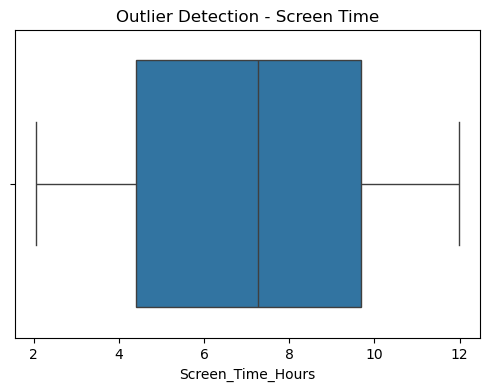

In [50]:
plt.figure(figsize = (6, 4))
sns.boxplot(x=df["Screen_Time_Hours"])
plt.title("Outlier Detection - Screen Time")
plt.show()

### 11. CREATE CATEGORIES

In [56]:
df["Addiction_Level"] = pd.cut(df["Screen_Time_Hours"],
                              bins=[0,4,8,12],
                              labels=["Low", "Medium", "High"])

df["Sleep_Category"] = pd.cut(df["Sleep_Hours"],
                             bins=[0,5,7,10],
                             labels=["Poor", "Average", "Good"])

### 12. FINAL CHECK

In [59]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   User_ID              500 non-null    object  
 1   Age                  500 non-null    int32   
 2   Gender               500 non-null    object  
 3   Screen_Time_Hours    500 non-null    float64 
 4   Sleep_Hours          500 non-null    float64 
 5   App_Usage            500 non-null    object  
 6   Steps                500 non-null    float64 
 7   Mood                 500 non-null    object  
 8   Work_Hours           500 non-null    float64 
 9   Social_Interactions  500 non-null    int64   
 10  Health_Score         500 non-null    float64 
 11  Addiction_Level      500 non-null    category
 12  Sleep_Category       500 non-null    category
dtypes: category(2), float64(5), int32(1), int64(1), object(4)
memory usage: 42.4+ KB


User_ID                0
Age                    0
Gender                 0
Screen_Time_Hours      0
Sleep_Hours            0
App_Usage              0
Steps                  0
Mood                   0
Work_Hours             0
Social_Interactions    0
Health_Score           0
Addiction_Level        0
Sleep_Category         0
dtype: int64

### 13. SAVE CLEAN DATA

In [78]:
df.to_csv("final_behavior_data.csv", index=False)

### 1. IMPORT + SET STYLE

In [81]:
df = pd.read_csv("final_behavior_data.csv")

sns.set(style="whitegrid")   # clean professional look

### 2. KPI DASHBOARD

In [86]:
print("📊 KEY METRICS")
print("Avg Screen Time:", round(df["Screen_Time_Hours"].mean(),2))
print("Avg Sleep:", round(df["Sleep_Hours"].mean(),2))
print("Avg Steps:", round(df["Steps"].mean(),2))

📊 KEY METRICS
Avg Screen Time: 7.09
Avg Sleep: 6.49
Avg Steps: 8108.66


### 3. SCREEN TIME VS SLEEP

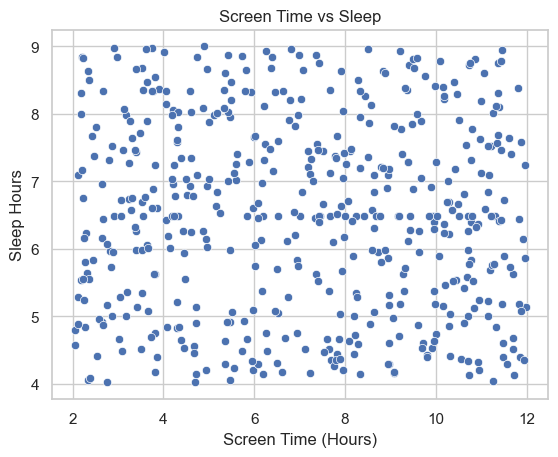

In [96]:
plt.figure()
sns.scatterplot(x="Screen_Time_Hours", y="Sleep_Hours", data=df)
plt.title("Screen Time vs Sleep")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Sleep Hours")
plt.show()

### 4. MOOD DISTRIBUTION

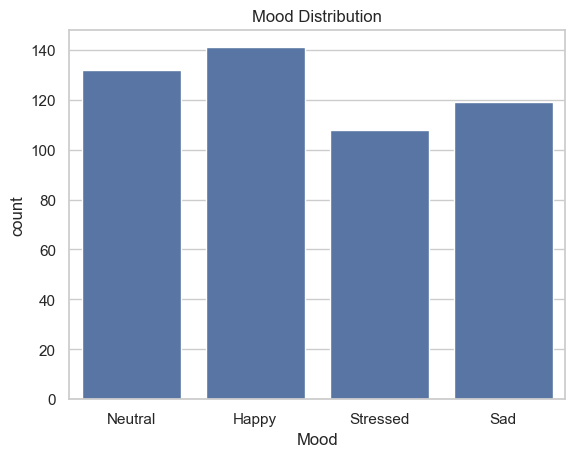

In [94]:
plt.figure()
sns.countplot(x="Mood", data=df)
plt.title("Mood Distribution")
plt.show()

### 5. ADDICTION LEVEL 

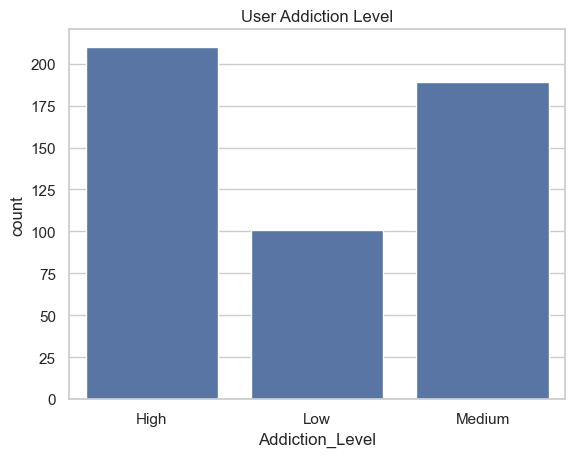

In [99]:
plt.figure()
sns.countplot(x="Addiction_Level", data=df)
plt.title("User Addiction Level")
plt.show()

### 6. SCREEN TIME IMPACT ON MOOD 

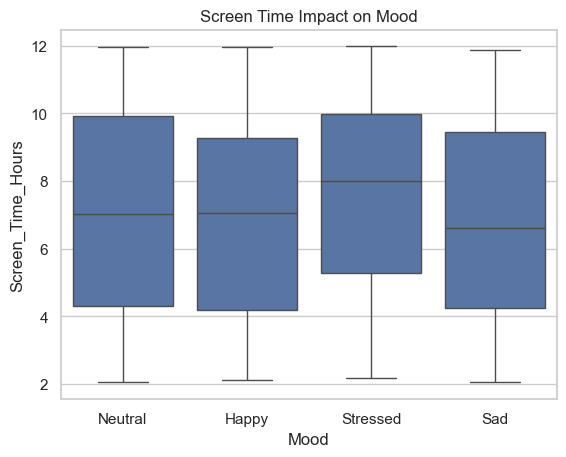

In [103]:
plt.figure()
sns.boxplot(x="Mood", y="Screen_Time_Hours", data=df)
plt.title("Screen Time Impact on Mood")
plt.show()

### 7. APP USAGE VS PHYSICAL ACTIVITY

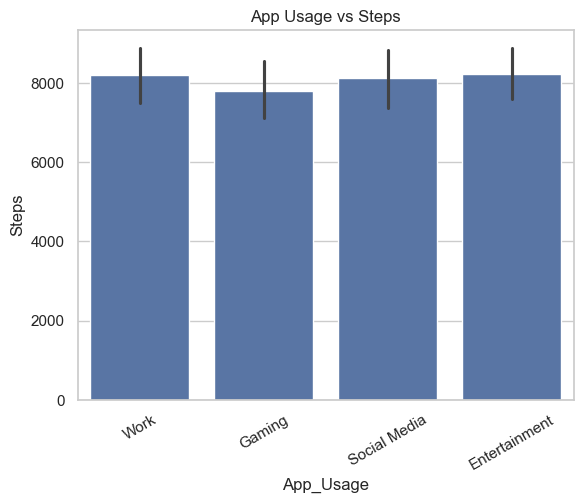

In [105]:
plt.figure()
sns.barplot(x="App_Usage", y="Steps", data=df)
plt.title("App Usage vs Steps")
plt.xticks(rotation=30)
plt.show()

### 8. CORRELATION HEATMAP

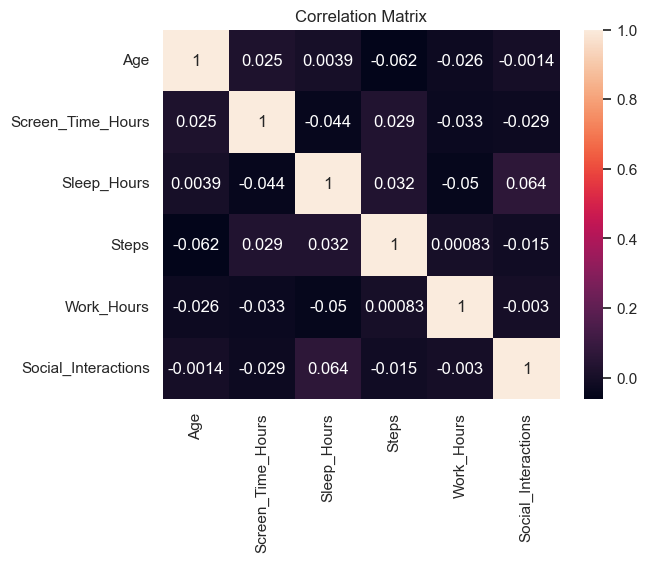

In [112]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

### DASHBOARD IN ONE CELL

C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128640 (\N{ROCKET}) missing from current font.
  fig.canvas.draw()
C:\Users\Admin\AppData\Local\Temp\ipykernel_2976\2616114096.py:60: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


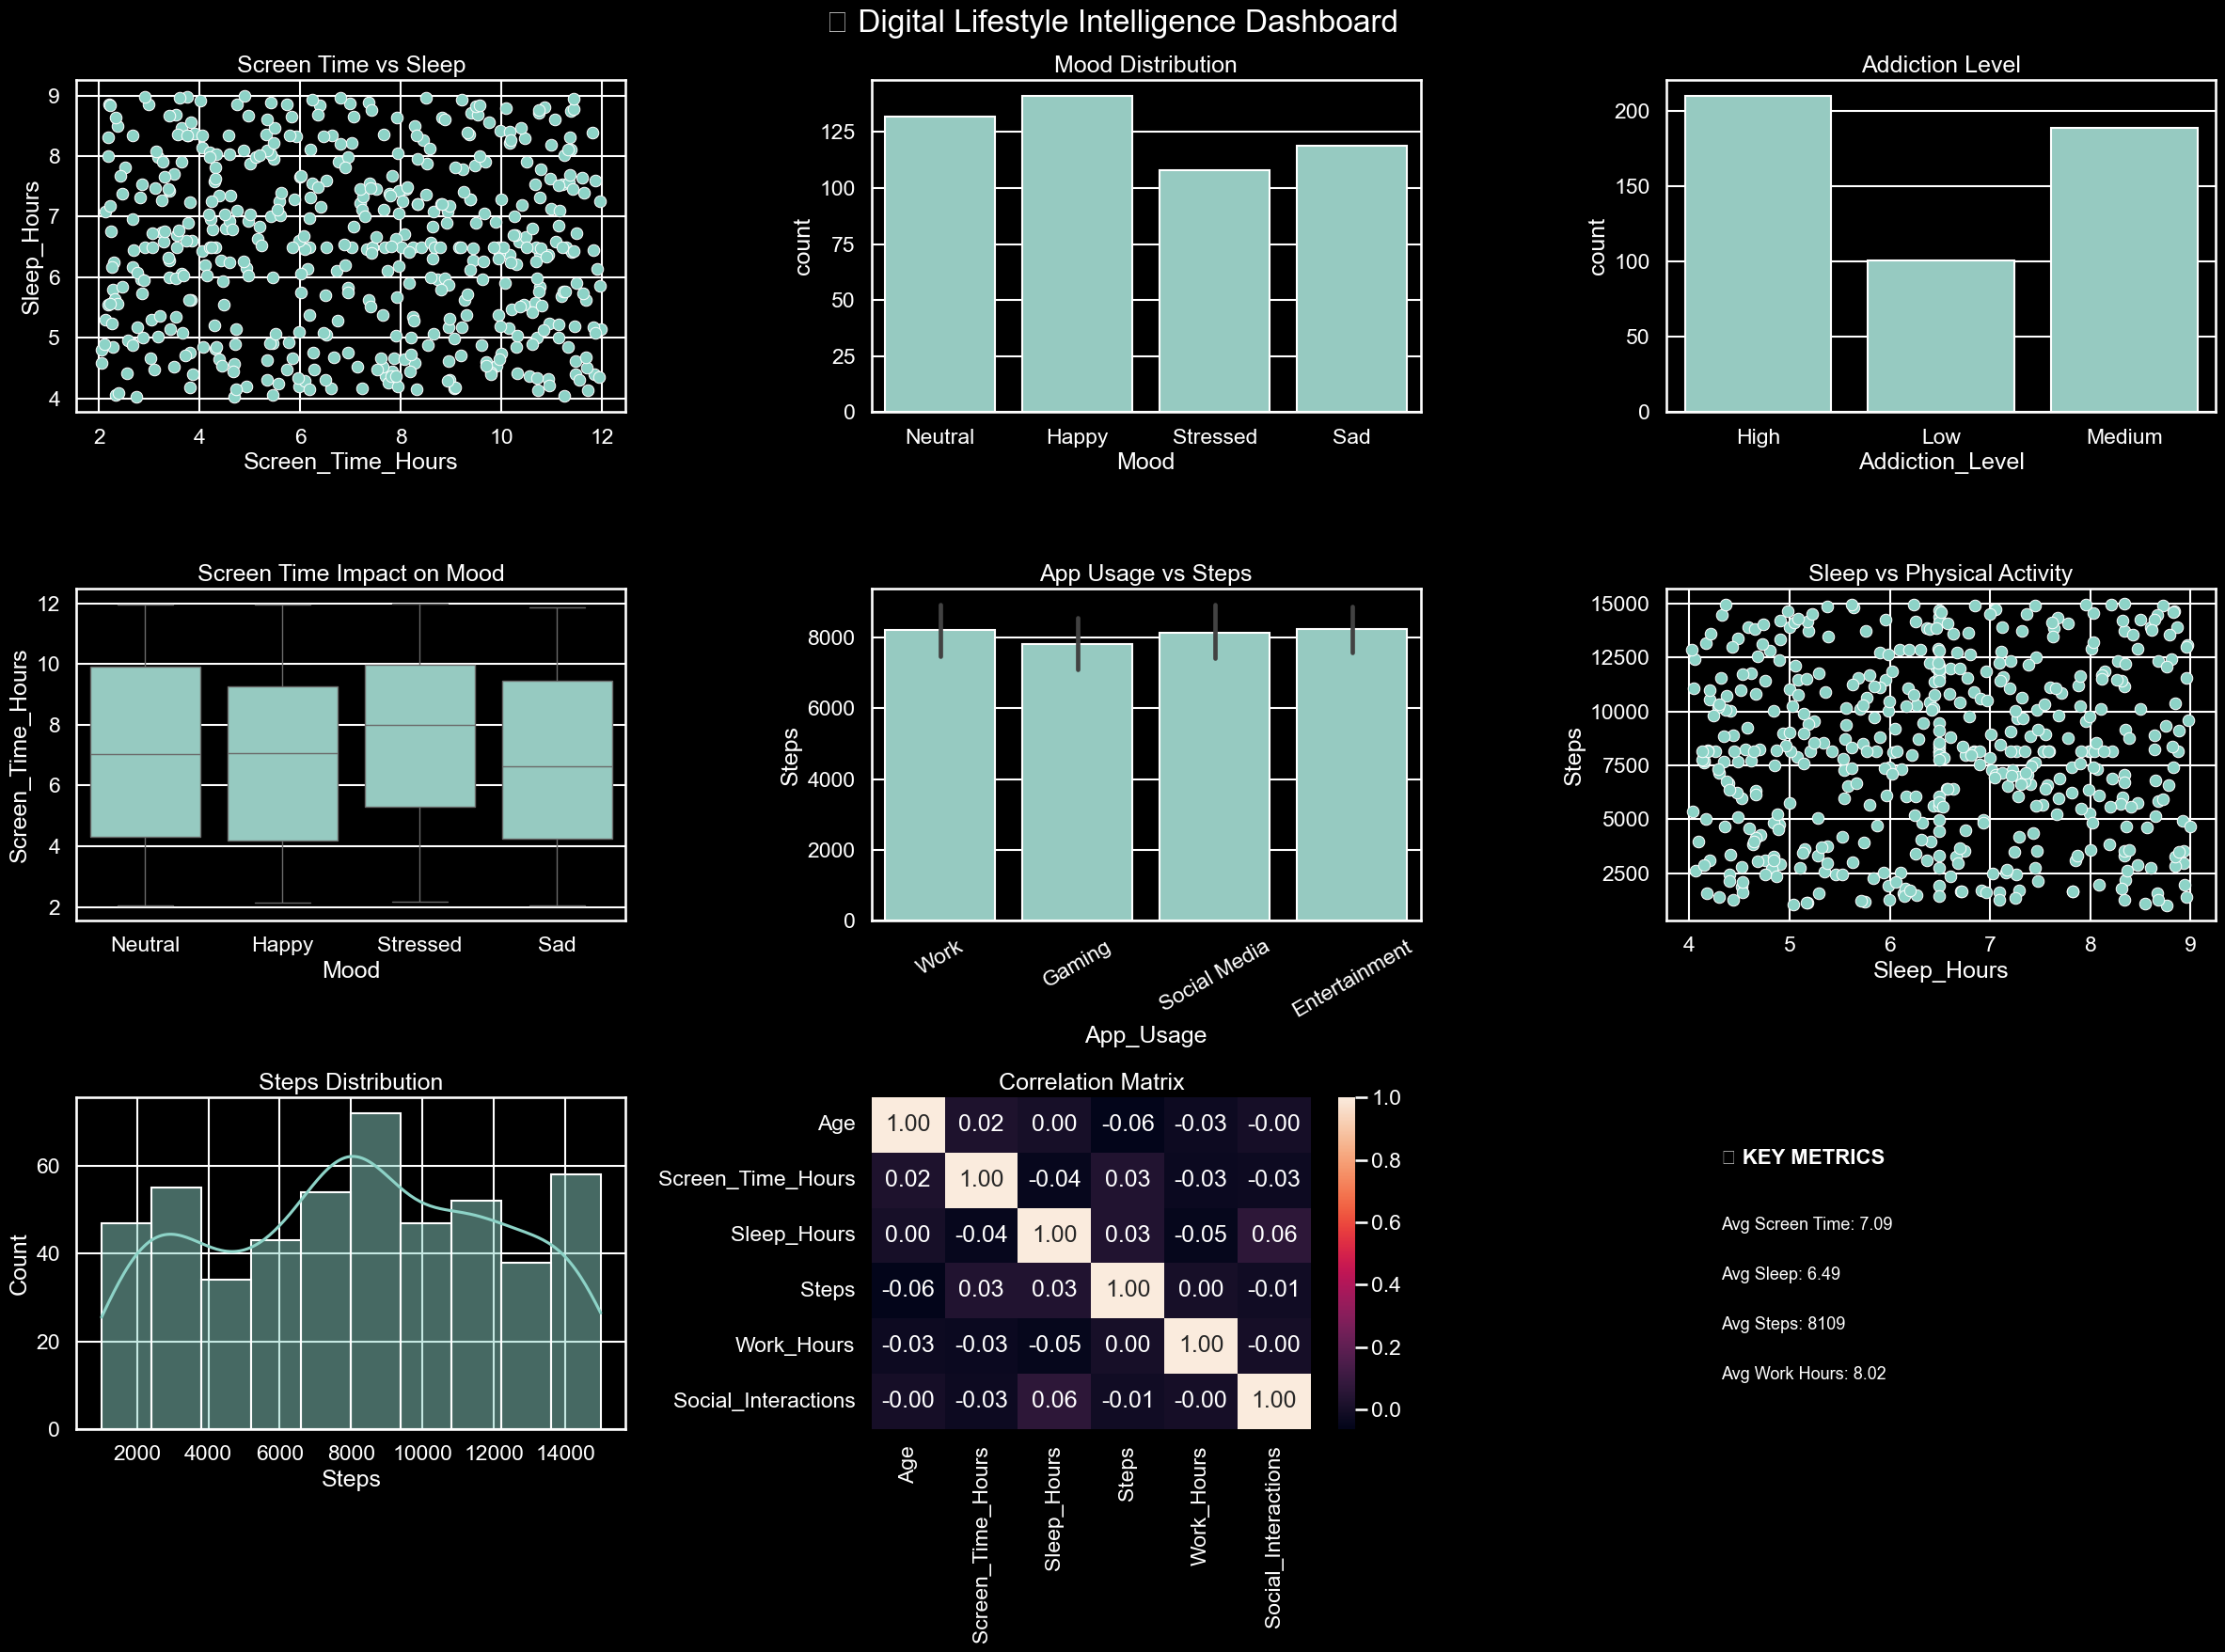

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load data
df = pd.read_csv("final_behavior_data.csv")

# 🌙 Dark Theme Style
plt.style.use("dark_background")
sns.set_context("talk")

# Create layout
fig, axes = plt.subplots(3, 3, figsize=(24, 18))

fig.suptitle("🚀 Digital Lifestyle Intelligence Dashboard", fontsize=24, color='white')

# 1. Screen Time vs Sleep
sns.scatterplot(ax=axes[0,0], x="Screen_Time_Hours", y="Sleep_Hours", data=df)
axes[0,0].set_title("Screen Time vs Sleep")

# 2. Mood Distribution
sns.countplot(ax=axes[0,1], x="Mood", data=df)
axes[0,1].set_title("Mood Distribution")

# 3. Addiction Level
sns.countplot(ax=axes[0,2], x="Addiction_Level", data=df)
axes[0,2].set_title("Addiction Level")

# 4. Screen Time vs Mood
sns.boxplot(ax=axes[1,0], x="Mood", y="Screen_Time_Hours", data=df)
axes[1,0].set_title("Screen Time Impact on Mood")

# 5. App Usage vs Steps
sns.barplot(ax=axes[1,1], x="App_Usage", y="Steps", data=df)
axes[1,1].set_title("App Usage vs Steps")
axes[1,1].tick_params(axis='x', rotation=30)

# 6. Sleep vs Steps
sns.scatterplot(ax=axes[1,2], x="Sleep_Hours", y="Steps", data=df)
axes[1,2].set_title("Sleep vs Physical Activity")

# 7. Steps Distribution
sns.histplot(ax=axes[2,0], x=df["Steps"], kde=True)
axes[2,0].set_title("Steps Distribution")

# 8. Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), ax=axes[2,1], annot=True, fmt=".2f")
axes[2,1].set_title("Correlation Matrix")

# 9. KPI Panel (Styled)
axes[2,2].axis('off')

axes[2,2].text(0.1, 0.8, "📊 KEY METRICS", fontsize=16, weight='bold')

axes[2,2].text(0.1, 0.6, f"Avg Screen Time: {df['Screen_Time_Hours'].mean():.2f}", fontsize=13)
axes[2,2].text(0.1, 0.45, f"Avg Sleep: {df['Sleep_Hours'].mean():.2f}", fontsize=13)
axes[2,2].text(0.1, 0.3, f"Avg Steps: {df['Steps'].mean():.0f}", fontsize=13)
axes[2,2].text(0.1, 0.15, f"Avg Work Hours: {df['Work_Hours'].mean():.2f}", fontsize=13)

plt.tight_layout()
plt.show()